# Analysis of Semantic Communication Experiment Results
This notebook loads the experimental output from `../results/experiment_results.csv` and visualizes the noise robustness and compression ratio of the semantic image communication pipeline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set base plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load the Dataset
Read the aggregated CSV results saved by the experiment sweep.

In [2]:
df = pd.read_csv("../results/experiment_results.csv")

# Group metrics by noise level and compute averages across the image dataset
summary = df.groupby("noise_level").agg({
    "semantic_score": "mean",
    "object_match_accuracy": "mean",
    "relation_match_accuracy": "mean",
    "compression_ratio": "mean"
}).reset_index()

summary.head(20)

,noise_level,semantic_score,object_match_accuracy,relation_match_accuracy,compression_ratio
0,0.0,1.0,1.000000,1.0,38727.563218
1,0.1,1.0,1.000000,1.0,38727.563218
2,0.2,1.0,1.000000,1.0,38727.563218
3,0.3,1.0,1.000000,1.0,38727.563218
4,0.4,1.0,1.000000,1.0,38727.563218
5,0.5,0.9,0.833333,1.0,112309.933333
6,0.6,0.9,0.833333,1.0,112309.933333
7,0.7,0.9,0.833333,1.0,112309.933333
8,0.8,0.9,0.833333,1.0,112309.933333


## 2. Average Semantic Score vs. Noise Level
Visualize the decay of the composite semantic fidelity score as channel noise increases.

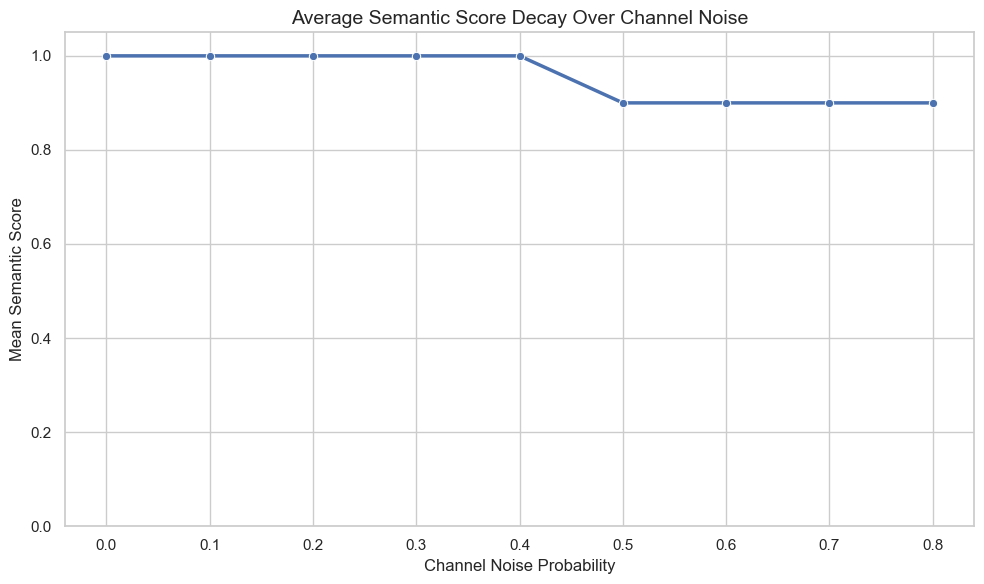

In [3]:
plt.figure()
sns.lineplot(data=summary, x="noise_level", y="semantic_score", marker="o", linewidth=2.5)
plt.title("Average Semantic Score Decay Over Channel Noise", fontsize=14)
plt.xlabel("Channel Noise Probability", fontsize=12)
plt.ylabel("Mean Semantic Score", fontsize=12)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 3. Object & Relation Accuracy vs. Noise Level
Compare how objects and relations individually degrade under the same channel noise.

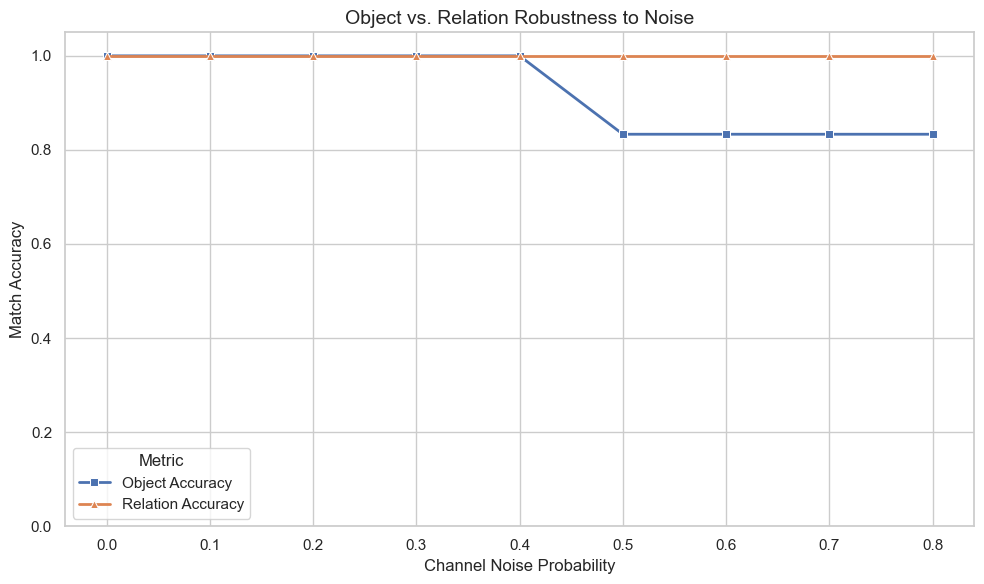

In [4]:
plt.figure()
sns.lineplot(data=summary, x="noise_level", y="object_match_accuracy", marker="s", label="Object Accuracy", linewidth=2)
sns.lineplot(data=summary, x="noise_level", y="relation_match_accuracy", marker="^", label="Relation Accuracy", linewidth=2)

plt.title("Object vs. Relation Robustness to Noise", fontsize=14)
plt.xlabel("Channel Noise Probability", fontsize=12)
plt.ylabel("Match Accuracy", fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 4. Average Compression Ratio by Noise
Visualize the average compression ratio (original image bytes vs. semantic token bytes) using a bar chart across the simulated noise levels.

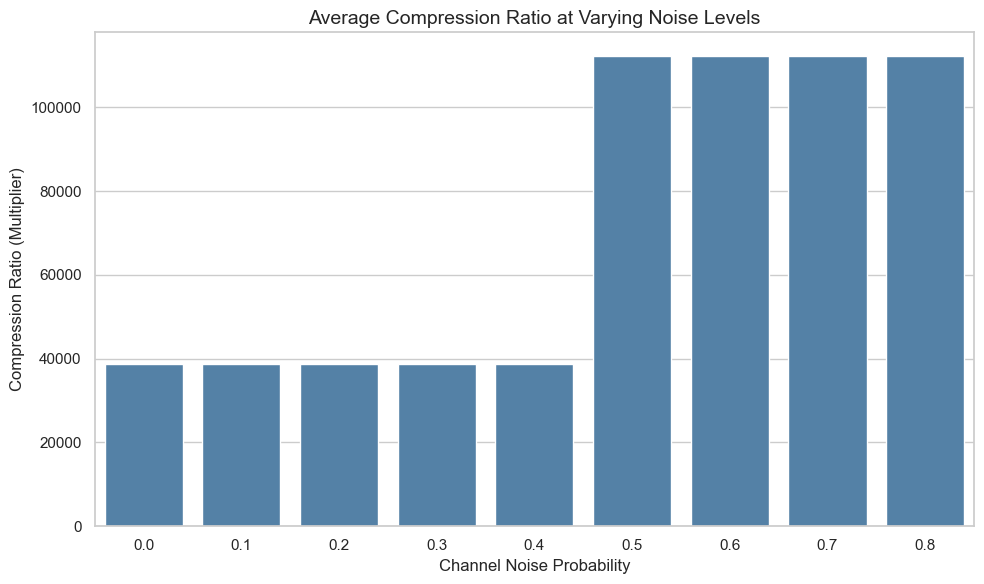

In [5]:
plt.figure()
sns.barplot(data=summary, x="noise_level", y="compression_ratio", color="steelblue")
plt.title("Average Compression Ratio at Varying Noise Levels", fontsize=14)
plt.xlabel("Channel Noise Probability", fontsize=12)
plt.ylabel("Compression Ratio (Multiplier)", fontsize=12)
plt.tight_layout()
plt.show()